# Wprowadzenie do zadania: Dźwięki i szeregi Fouriera

Każdy dźwięk, który słyszymy, jest falą ciśnienia powietrza zmieniającą się w czasie. W komputerze i cyfrowych systemach audio fale te reprezentujemy jako *próbki*, czyli wartości amplitudy w określonych momentach czasu (to samo co omawiany kilka wykładów temu sampling).

## 1. Szeregi Fouriera a dźwięki

Matematycznie każdą falę okresową można przedstawić jako sumę sinusów i cosinusów o różnych częstotliwościach i amplitudach. Taki zapis nazywamy **szeregiem Fouriera**.  

W skrócie:

$$
x(t) \approx \sum_{n=1}^{N} a_n \cos(2 \pi n f_0 t + \phi_n)
$$

- $x(t)$ -- sygnał (fala dźwiękowa) w czasie $t$  
- $f_0$ -- częstotliwość podstawowa (np. dźwięk A4 = 440 Hz)  
- $n f_0$ -- częstotliwości kolejnych harmonicznych (2$f_0$, 3$f_0$, …)  
- $a_n$ -- amplituda $n$-tej harmonicznej  
- $\phi_n$ -- przesunięcie fazowe $n$-tej harmonicznej  

Intuicyjnie: *ton podstawowy* decyduje o wysokości dźwięku, a kolejne harmoniczne dodają *barwę* (czyli charakterystyczny „kolor” dźwięku, np. fortepian vs gitara).

## 2. Szereg Fouriera w praktyce

- Jeśli zsumujemy tylko jedną harmoniczną ($n=1$) → otrzymamy *czysty sinus*.  
- Dodając kolejne harmoniczne ($n=2,3,…$) → dźwięk staje się bardziej „instrumentowy”.  
- Liczba harmonicznych i ich amplitudy decydują o tym, jak brzmi dana nuta.

## 3. Cel zadania

W tym zadaniu:

1. Wygenerujesz poszczególne dźwięki gamy (np. C3–C4) jako sumę harmonicznych.  
2. Połączysz je w jedną sekwencję, aby zagrać *melodyjkę*.  
3. Narysujesz wykres fali dźwiękowej, aby zobaczyć, jak wygląda suma harmonicznych w czasie.  

Dzięki temu *zobaczysz w praktyce*, jak szeregi Fouriera opisują fale dźwiękowe i jak zmienia się barwa dźwięku w zależności od liczby harmonicznych.


Rozpoczniemy od niezbędnych importów i parametrów.

In [13]:
import numpy as np
from IPython.display import Audio, display
import matplotlib.pyplot as plt

# Parametry dźwięku
fs = 44100          # częstotliwość próbkowania [Hz]
czas = 0.6          # czas trwania pojedynczej nuty [s]
N_harmonics = 10    # liczba harmonicznych do zsumowania

# Mapa nut i częstotliwości

W kolejnej komórce zdefiniujemy **mapę nut** dla jednej oktawy C3–C4, uwzględniając także B♭3 (B flat).  

- Każda nuta jest kluczem w słowniku (`note_freqs`)  
- Wartością jest jej częstotliwość w Hz  
- Przykład: `'A3': 220.0` oznacza, że dźwięk A3 ma częstotliwość 220 Hz  

Ta mapa pozwala nam w prosty sposób generować sygnały dla poszczególnych nut, korzystając z funkcji, która sumuje harmoniczne.  
Dzięki temu możemy łatwo zbudować gamę lub melodię, odwołując się do nut po nazwach zamiast wpisywać częstotliwości ręcznie.

In [9]:
# Mapa nut z częstotliwościami (C3–C4 + B♭3)
note_freqs = {
    'C3': 130.81,
    'D3': 146.83,
    'E3': 164.81,
    'F3': 174.61,
    'G3': 196.00,
    'A3': 220.00,
    'B3': 233.08,
    'H3': 246.94,
    'C4': 261.63
}

# Funkcja `make_tone`

Ta funkcja tworzy **pojedynczą nutę** jako sumę sinusów – czyli jej **harmonicznych**. Dzięki temu dźwięk nie jest "czystym sinusoidą", tylko ma barwę, podobną do fortepianu lub gitary.

- `f0` – częstotliwość podstawowa nuty (np. A3 = 220 Hz)  
- `duration` – czas trwania nuty w sekundach  
- `fs` – liczba próbek na sekundę (czyli jak często komputer sprawdza wartość fali)  
- `N` – liczba harmonicznych do zsumowania  

**Jak to działa w praktyce:**
1. Tworzymy wektor czasu `t` od 0 do czasu trwania nuty.  
2. Inicjalizujemy sygnał zerami.  
3. Dodajemy kolejne harmoniczne: każda kolejna jest wielokrotnością częstotliwości podstawowej i ma coraz mniejszą amplitudę (1/n).  
4. Na końcu **normalizujemy** sygnał, żeby amplituda mieściła się w zakresie -1 do 1.

Dzięki tej funkcji możemy później generować wszystkie nuty gamy i je odtwarzać.

# Jak zsumować harmoniczne?

Każda nuta może być przedstawiona jako **suma harmonicznych** swojego tonu podstawowego.  
Niech $f_0$ będzie częstotliwością podstawową nuty, a $N$ liczbą harmonicznych.  

Sygnał $x(t)$ można zapisać jako:

$
x(t) = \sum_{n=1}^{N} \frac{1}{n} \cos(2 \pi n f_0 t)
$

gdzie:  
- $n$ – numer harmonicznej (1 = ton podstawowy, 2 = druga harmoniczna, …)  
- $f_0$ – częstotliwość podstawowa nuty  
- $t$ – czas  
- $\frac{1}{n}$ – współczynnik zmniejszający amplitudę kolejnych harmonicznych  

Po zsumowaniu wszystkich harmonicznych sygnał należy **znormalizować**, aby maksymalna wartość amplitudy wynosiła 1:

$
x(t) \leftarrow \frac{x(t)}{\max |x(t)|}
$

In [17]:
# Funkcja generująca pojedynczy dźwięk jako sumę harmonicznych
def make_tone(f0, duration, fs, N):
    """
    f0       : częstotliwość podstawowa nuty [Hz]
    duration : czas trwania nuty [s]
    fs       : częstotliwość próbkowania [Hz]
    N        : liczba harmonicznych do zsumowania
    """
    # Tworzymy wektor czasu od 0 do duration
    t = np.linspace(0, duration, int(fs*duration), endpoint=False)

    # Inicjalizacja sygnału zerami
    sig = np.zeros_like(t)

    # TODO: zsumuj N harmonicznych (w sig)
    for n in range(1, N+1):
        #if n*f0 >= fs/2:
            #break
        sig += (1/n) * np.cos(2*np.pi*n*f0*t)

    # TODO: normalizacja sygnału
    sig /= np.max(np.abs(sig))  # normalizacja

    return sig

# Jak zbudować gamę z poszczególnych nut

Aby zagrać melodyjkę, łączymy **pojedyncze nuty** w jeden ciągły sygnał.  

## Krok po kroku:

1. **Wybieramy kolejność nut** – np. C3, D3, E3, F3, G3, A3, B3, H3, C4.  
2. **Generujemy każdą nutę** przy użyciu funkcji `make_tone`:
   - Podajemy częstotliwość nuty, czas trwania, liczbę próbek i liczbę harmonicznych.  
3. **Dodajemy krótką pauzę** (np. kilka milisekund) między nutami, żeby dźwięki były rozróżnialne.  
4. **Łączymy wszystkie nuty i pauzy** w jeden sygnał, np. za pomocą funkcji `np.concatenate`.  
5. **Odtwarzamy sygnał** w notebooku lub zapisujemy do pliku audio.

In [18]:
# Budowanie gamy i odtwarzanie dźwięku

sequence = []
pauza = np.zeros(int(0.05*fs))  # krótka pauza między nutami (50 ms)


#TODO: tutaj możesz podstawić własną melodyjkę. Czym jest podana melodyjka?
for note in ['C3', 'C3', 'D3', 'C3', 'F3','E3' ,'C3', 'C3', 'D3','C3', 'G3','F3','C3','C3','C4','A3','F3','D3','B3','B3','A3','F3','G3','F3']:
    # TODO: wygeneruj pojedynczy ton za pomocą make_tone
    tone=make_tone(note_freqs[note], czas, fs, N_harmonics)

    # dodaj ton i pauzę do sekwencji
    sequence.append(tone)
    sequence.append(pauza)

# łączymy wszystkie nuty w jeden sygnał
calosc = np.concatenate(sequence)

# TODO: odtwórz gamę w notebooku
display(Audio(calosc, rate=fs))

# Rysowanie fali dźwiękowej gamy

Po wygenerowaniu całej gamy możemy zobaczyć, jak wygląda suma harmonicznych w czasie.  

W tej komórce:

1. Tworzymy wektor czasu `t_total`, który odpowiada każdej próbce sygnału.  
   - Liczba punktów wektora musi być taka sama, jak liczba próbek w `calosc`.  
   - Zakres czasu idzie od 0 do długości całego sygnału w sekundach.  

2. Rysujemy wykres amplitudy sygnału w funkcji czasu (`calosc` w funkcji `t_total`).  

3. Opcjonalnie ustawiamy zakres osi x (`plt.xlim`), żeby zobaczyć np. tylko pierwszą nutę lub fragment całej gamy.  

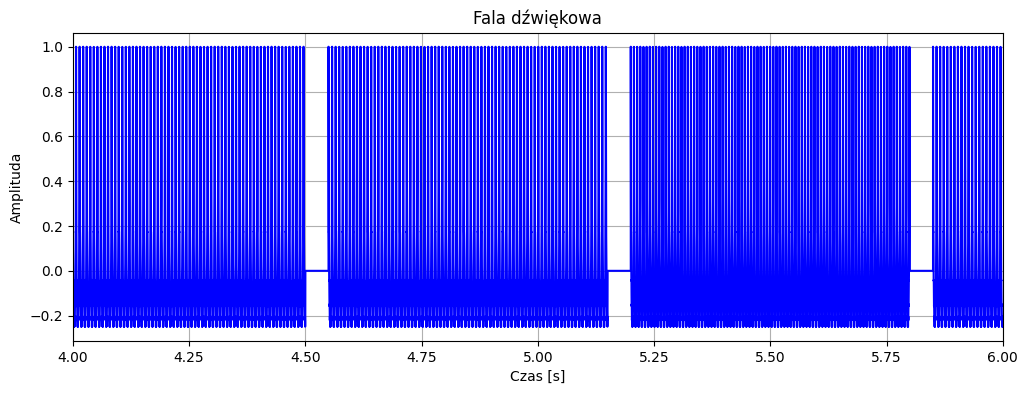

In [19]:
# Rysowanie fali dźwiękowej gamy

# TODO: stwórz wektor czasu odpowiadający całemu sygnałowi
t_total = np.linspace(0, len(calosc)/fs, len(calosc), endpoint=False)

plt.figure(figsize=(12,4))
plt.plot(t_total, calosc, color='blue')
plt.title("Fala dźwiękowa")
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")

# TODO: ustaw zakres osi x, np. aby pokazać tylko pierwsze 0.5 s
plt.xlim(4, 6)

plt.grid(True)
plt.show()